In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# Plot settings
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)

print("Libraries loaded successfully")
print(f"Pandas: {pd.__version__}")

Libraries loaded successfully
Pandas: 2.2.2


In [2]:
# Test loading one file first
# Path goes up two levels (../..) from data_preprocessing folder to project root, then into 02_Datasets/raw
file_path = "../../02_Datasets/raw/PUB_Demand_2024.csv"

# Read CSV, skip first 3 header rows
df_2024 = pd.read_csv(file_path, skiprows=3)

print(f"Loaded 2024 data: {len(df_2024)} rows")
print(f"\nColumns: {list(df_2024.columns)}")
print(f"\nFirst 5 rows:")
df_2024.head()

Loaded 2024 data: 8784 rows

Columns: ['Date', 'Hour', 'Market Demand', 'Ontario Demand']

First 5 rows:


,Date,Hour,Market Demand,Ontario Demand
0,2024-01-01,1,17091,14482
1,2024-01-01,2,16658,14180
2,2024-01-01,3,16233,13722
3,2024-01-01,4,15909,13637
4,2024-01-01,5,15998,13697


In [3]:
# Load all years from 2010-2025
years = range(2010, 2026)  # 2010 through 2025
all_data = []

print("Loading IESO demand data...")
print("-" * 50)

for year in years:
    file_path = f"../../02_Datasets/raw/PUB_Demand_{year}.csv"
    
    try:
        # Load CSV, skip header rows
        df = pd.read_csv(file_path, skiprows=3)
        all_data.append(df)
        print(f"✓ {year}: {len(df):,} records")
        
    except FileNotFoundError:
        print(f"✗ {year}: File not found")

print("-" * 50)
print(f"Loaded {len(all_data)} files successfully")

# Merge all years into one dataframe
demand_data = pd.concat(all_data, ignore_index=True)

print(f"\nTotal dataset:")
print(f"  Rows: {len(demand_data):,}")
print(f"  Columns: {list(demand_data.columns)}")
print(f"  Memory: {demand_data.memory_usage(deep=True).sum() / 1024**2:.1f} MB")

Loading IESO demand data...
--------------------------------------------------
✓ 2010: 8,760 records
✓ 2011: 8,760 records
✓ 2012: 8,784 records
✓ 2013: 8,760 records
✓ 2014: 8,760 records
✓ 2015: 8,760 records
✓ 2016: 8,784 records
✓ 2017: 8,760 records
✓ 2018: 8,760 records
✓ 2019: 8,760 records
✓ 2020: 8,784 records
✓ 2021: 8,760 records
✓ 2022: 8,760 records
✓ 2023: 8,760 records
✓ 2024: 8,784 records
✓ 2025: 7,488 records
--------------------------------------------------
Loaded 16 files successfully

Total dataset:
  Rows: 138,984
  Columns: ['Date', 'Hour', 'Market Demand', 'Ontario Demand']
  Memory: 11.0 MB


In [4]:
# Check data types and missing values
print("Data Types:")
print(demand_data.dtypes)

print("\n" + "="*50)
print("Missing Values:")
print(demand_data.isnull().sum())

print("\n" + "="*50)
print("First 10 rows:")
demand_data.head(10)

Data Types:
Date              object
Hour               int64
Market Demand      int64
Ontario Demand     int64
dtype: object

Missing Values:
Date              0
Hour              0
Market Demand     0
Ontario Demand    0
dtype: int64

First 10 rows:


,Date,Hour,Market Demand,Ontario Demand
0,2010-01-01,1,16025,14403
1,2010-01-01,2,15428,13814
2,2010-01-01,3,15291,13366
3,2010-01-01,4,15482,13120
4,2010-01-01,5,15508,13075
5,2010-01-01,6,15662,13234
6,2010-01-01,7,15689,13534
7,2010-01-01,8,16066,13698
8,2010-01-01,9,16120,13814
9,2010-01-01,10,16705,14273


In [5]:
# Create proper datetime column
demand_data['DateTime'] = pd.to_datetime(demand_data['Date']) + pd.to_timedelta(demand_data['Hour'] - 1, unit='h')

# Extract useful time features for ML
demand_data['Year'] = demand_data['DateTime'].dt.year
demand_data['Month'] = demand_data['DateTime'].dt.month
demand_data['DayOfWeek'] = demand_data['DateTime'].dt.dayofweek  # 0=Monday, 6=Sunday
demand_data['DayOfYear'] = demand_data['DateTime'].dt.dayofyear
demand_data['IsWeekend'] = (demand_data['DayOfWeek'] >= 5).astype(int)  # 1 if Sat/Sun, 0 otherwise

# Reorder columns to put DateTime first
columns = ['DateTime', 'Date', 'Hour', 'Year', 'Month', 'DayOfWeek', 'DayOfYear', 'IsWeekend', 
           'Market Demand', 'Ontario Demand']
demand_data = demand_data[columns]

print("Added time features")
print(f"\nDate range: {demand_data['DateTime'].min()} to {demand_data['DateTime'].max()}")
print(f"\nDataset now has {len(demand_data.columns)} columns:")
print(demand_data.columns.tolist())
print("\nFirst 5 rows:")
demand_data.head()

Added time features

Date range: 2010-01-01 00:00:00 to 2025-11-09 00:00:00

Dataset now has 10 columns:
['DateTime', 'Date', 'Hour', 'Year', 'Month', 'DayOfWeek', 'DayOfYear', 'IsWeekend', 'Market Demand', 'Ontario Demand']

First 5 rows:


,DateTime,Date,Hour,Year,Month,DayOfWeek,DayOfYear,IsWeekend,Market Demand,Ontario Demand
0,2010-01-01 00:00:00,2010-01-01,1,2010,1,4,1,0,16025,14403
1,2010-01-01 01:00:00,2010-01-01,2,2010,1,4,1,0,15428,13814
2,2010-01-01 02:00:00,2010-01-01,3,2010,1,4,1,0,15291,13366
3,2010-01-01 03:00:00,2010-01-01,4,2010,1,4,1,0,15482,13120
4,2010-01-01 04:00:00,2010-01-01,5,2010,1,4,1,0,15508,13075


In [6]:
# Basic statistics
print("Ontario Demand Statistics (MW):")
print(demand_data['Ontario Demand'].describe())

print("\n" + "="*50)
print("Peak demand:")
peak_idx = demand_data['Ontario Demand'].idxmax()
print(f"  {demand_data.loc[peak_idx, 'Ontario Demand']} MW on {demand_data.loc[peak_idx, 'DateTime']}")

print("\nMinimum demand:")
min_idx = demand_data['Ontario Demand'].idxmin()
print(f"  {demand_data.loc[min_idx, 'Ontario Demand']} MW on {demand_data.loc[min_idx, 'DateTime']}")

print("\n" + "="*50)
print("Records by year:")
print(demand_data.groupby('Year')['Ontario Demand'].count())

Ontario Demand Statistics (MW):
count    138984.000000
mean      15746.262584
std        2392.803721
min        9831.000000
25%       13978.000000
50%       15659.000000
75%       17345.000000
max       25450.000000
Name: Ontario Demand, dtype: float64

Peak demand:
  25450 MW on 2011-07-21 15:00:00

Minimum demand:
  9831 MW on 2020-05-18 03:00:00

Records by year:
Year
2010    8760
2011    8760
2012    8784
2013    8760
2014    8760
2015    8760
2016    8784
2017    8760
2018    8760
2019    8760
2020    8784
2021    8760
2022    8760
2023    8760
2024    8784
2025    7488
Name: Ontario Demand, dtype: int64


In [7]:
# Save cleaned data
output_path = "../../02_Datasets/processed/ieso_demand_2010_2025_cleaned.csv"
demand_data.to_csv(output_path, index=False)

print(f"✓ Saved cleaned dataset to:")
print(f"  {output_path}")
print(f"\nFile size: {os.path.getsize(output_path) / 1024**2:.1f} MB")
print(f"Rows: {len(demand_data):,}")
print(f"Columns: {len(demand_data.columns)}")

✓ Saved cleaned dataset to:
  ../../02_Datasets/processed/ieso_demand_2010_2025_cleaned.csv

File size: 8.2 MB
Rows: 138,984
Columns: 10


✓ Saved figure to: ../../04_Presentation/daily_demand_pattern.png


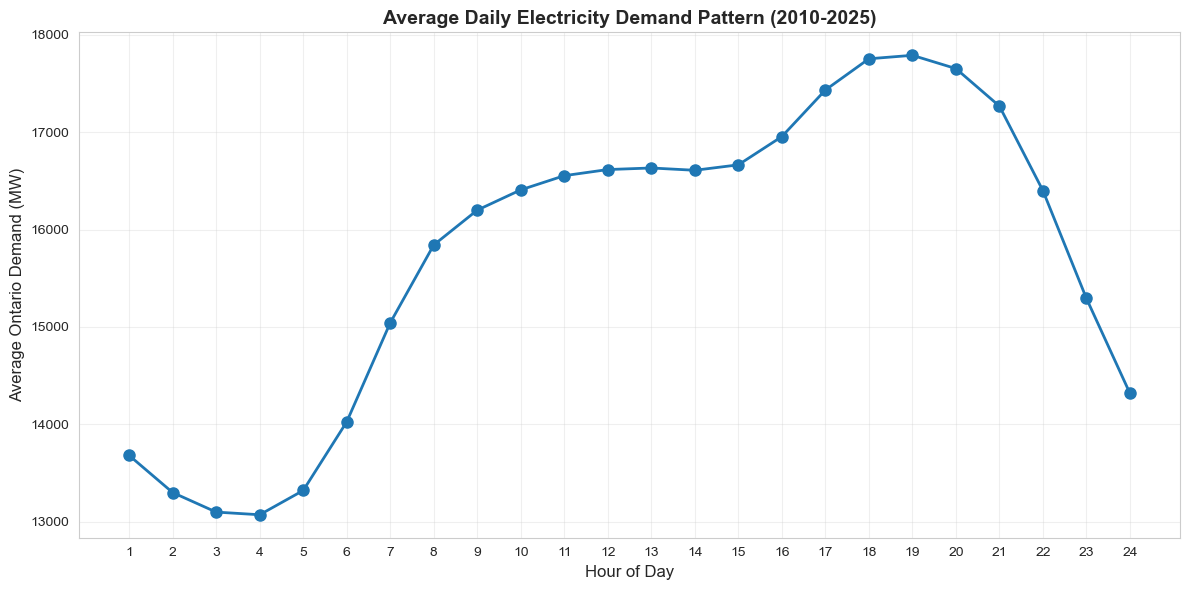

In [8]:
# Calculate average demand by hour of day
hourly_pattern = demand_data.groupby('Hour')['Ontario Demand'].mean()

# Create plot
plt.figure(figsize=(12, 6))
plt.plot(hourly_pattern.index, hourly_pattern.values, marker='o', linewidth=2, markersize=8)
plt.xlabel('Hour of Day', fontsize=12)
plt.ylabel('Average Ontario Demand (MW)', fontsize=12)
plt.title('Average Daily Electricity Demand Pattern (2010-2025)', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.xticks(range(1, 25))
plt.tight_layout()

# Save figure
fig_path = "../../04_Presentation/daily_demand_pattern.png"
plt.savefig(fig_path, dpi=300, bbox_inches='tight')
print(f"✓ Saved figure to: {fig_path}")

plt.show()

## Summary

**Dataset:** IESO Ontario Electricity Demand (2010-2025)

**What was done:**
1. Loaded 16 years of hourly demand data (2010-2025)
2. Merged all years into single dataset: **138,984 hourly records**
3. Added temporal features: Year, Month, DayOfWeek, DayOfYear, IsWeekend
4. Created proper DateTime column for time series analysis
5. Saved cleaned dataset to `processed/` folder

**Key Statistics:**
- Average Demand: 15,746 MW
- Peak: 25,450 MW (July 21, 2011 @ 3 PM)
- Minimum: 9,831 MW (May 18, 2020 @ 3 AM - COVID lockdown)
- No missing values ✓

**Next Steps:**
- Download weather data (Environment Canada)
- Merge weather features with demand data
- Begin ML modeling